In [79]:
pip install langchain langgraph groq pdf2image pytesseract pillow python-dotenv langchain_openai

In [80]:
!sudo apt install tesseract-ocr poppler-utils -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
tesseract-ocr is already the newest version (4.1.1-2.1build1).
poppler-utils is already the newest version (22.02.0-2ubuntu0.12).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


In [81]:
import os
import sqlite3
import csv
from typing import TypedDict, List

from pdf2image import convert_from_path
import pytesseract
from dotenv import load_dotenv

from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage
from langchain.tools import tool

from langgraph.graph import StateGraph, END
from langgraph.prebuilt import ToolNode
from langgraph.checkpoint.memory import MemorySaver

load_dotenv()

False

In [82]:

# -----------------------------
# CONFIG
# -----------------------------
DB_FILE = "documents.db"
CSV_FILE = "irrelevant_docs.csv"

In [83]:
# -----------------------------
# DATABASE
# -----------------------------
# Initialize database tables with a local connection
with sqlite3.connect(DB_FILE) as conn_init:
    cursor_init = conn_init.cursor()

    cursor_init.execute("""
    CREATE TABLE IF NOT EXISTS documents (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        file_name TEXT,
        document_name TEXT,
        document_date TEXT,
        extracted_details TEXT
    )
    """)

    cursor_init.execute("""
    CREATE TABLE IF NOT EXISTS audit_logs (
        id INTEGER PRIMARY KEY AUTOINCREMENT,
        file_name TEXT,
        classification TEXT,
        action TEXT,
        human_decision TEXT,
        timestamp DATETIME DEFAULT CURRENT_TIMESTAMP
    )
    """)
    conn_init.commit()

# -----------------------------
# CSV SETUP
# -----------------------------
if not os.path.exists(CSV_FILE):
    with open(CSV_FILE, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["file_name", "document_name", "document_date"])

In [84]:
# -----------------------------
# STORAGE FUNCTIONS
# -----------------------------
def save_valid_to_db(file_name, doc_name, doc_date, details):
    with sqlite3.connect(DB_FILE) as conn_local:
        cursor_local = conn_local.cursor()
        cursor_local.execute("""
            INSERT INTO documents (file_name, document_name, document_date, extracted_details)
            VALUES (?, ?, ?, ?)
        """, (file_name, doc_name, doc_date, str(details)))
        conn_local.commit()

def save_audit_log(file_name, classification, action, human_decision=""):
    with sqlite3.connect(DB_FILE) as conn_local:
        cursor_local = conn_local.cursor()
        cursor_local.execute("""
            INSERT INTO audit_logs (file_name, classification, action, human_decision)
            VALUES (?, ?, ?, ?)
        """, (file_name, classification, action, human_decision))
        conn_local.commit()

def save_irrelevant_to_csv(file_name, doc_name, doc_date):
    with open(CSV_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([file_name, doc_name, doc_date])

In [85]:
import os
from google.colab import userdata

# Retrieve the GROQ_API_KEY from Colab secrets
groq_api_key = userdata.get("GROQ_API_KEY")

# Set the environment variable
os.environ["GROQ_API_KEY"] = groq_api_key

print("GROQ_API_KEY environment variable has been set.")

GROQ_API_KEY environment variable has been set.


In [86]:
# -----------------------------
# LLM (Groq)
# -----------------------------
groq_api_key = os.getenv("GROQ_API_KEY")
if not groq_api_key:
    raise ValueError("GROQ_API_KEY environment variable not set. Please set it in your .env file or directly.")

llm = ChatOpenAI(
    openai_api_base="https://api.groq.com/openai/v1",
    openai_api_key=groq_api_key,
    model="llama-3.3-70b-versatile",
    temperature=0
)

In [87]:
# -----------------------------
# TOOLS (AGENTS)
# -----------------------------
@tool
def save_to_db_tool(document_name: str, document_date: str, key_details: str, file_name: str):
    """Saves valid document details to the database."""
    save_valid_to_db(file_name, document_name, document_date, key_details)
    print("\n✅ DB INSERT SUCCESS")
    print(f"File: {file_name}")
    print(f"Document Name: {document_name}")
    print(f"Document Date: {document_date}")
    print(f"Extracted Details: {key_details}")
    return "Saved to DB"

@tool
def save_to_csv_tool(document_name: str, document_date: str, file_name: str):
    """Saves irrelevant document details to a CSV file."""
    save_irrelevant_to_csv(file_name, document_name, document_date)
    print("\n📁 CSV WRITE SUCCESS")
    print(f"File: {file_name}")
    print(f"Document Name: {document_name}")
    print(f"Document Date: {document_date}")
    return "Saved to CSV"

tools = [save_to_db_tool, save_to_csv_tool]
llm_with_tools = llm.bind_tools(tools)

In [88]:

# -----------------------------
# STATE
# -----------------------------
class AgentState(TypedDict):
    file_path: str
    text: str
    messages: List
    classification: str
    human_decision: str

In [89]:
# -----------------------------
# OCR NODE
# -----------------------------
def ocr_node(state: AgentState):
    file_path = state["file_path"]
    file_name = os.path.basename(file_path)
    images = convert_from_path(state["file_path"])
    text = ""

    for img in images:
        text += pytesseract.image_to_string(img)

    ocr_file = f"{file_name}_ocr.txt"

    with open(ocr_file, "w", encoding="utf-8") as f:
        f.write(text)

    print(f"📁 Full OCR saved to: {ocr_file}")

    return {"text": text}

# -------------Detect keyword------------------------
def detect_keyword(text):
    text_lower = text.lower()

    valid_keywords = ["cease", "desist"]
    uncertain_keywords = ["behalf"]

    found_valid = [k for k in valid_keywords if k in text_lower]
    found_uncertain = [k for k in uncertain_keywords if k in text_lower]

    if found_valid:
        return "valid_keyword", found_valid

    if found_uncertain:
        return "uncertain_keyword", found_uncertain

    return "no_keyword", []

In [90]:
# -----------------------------
# AGENT NODE (LLM decides)
# -----------------------------
def agent_node(state: AgentState):
    file_name = os.path.basename(state["file_path"])
    keyword_type, keywords_found = detect_keyword(state["text"])

    print("\n📄 FILE:", file_name)
    print("🔍 Keyword Type:", keyword_type)
    print("🔑 Keywords Found:", keywords_found)

    prompt = f"""
Keyword classification already determined:

Keyword Type: {keyword_type}
Keywords Found: {keywords_found}

Rules:
- valid_keyword → call save_to_db_tool
- uncertain_keyword → DO NOT call tool
- no_keyword → call save_to_csv_tool

Extract:
- document_name
- document_date
- key_details

Document:
{state['text']}
    """

    response = llm_with_tools.invoke([HumanMessage(content=prompt)])

    # 🚨 FIX 1: FORCE HUMAN LOOP FOR UNCERTAIN
    if keyword_type == "uncertain_keyword":
        print("⚠️ FORCED HUMAN REVIEW (UNCERTAIN KEYWORD)")

        return {
            "messages": [response],
            "classification": "uncertain",
            "keyword_type": keyword_type,
            "tool_used": "none"
        }

    # ✅ VALID / IRRELEVANT FLOW
    if hasattr(response, "tool_calls") and response.tool_calls:
        tool_name = response.tool_calls[0]["name"]

        print("🤖 Tool Invoked by LLM:", tool_name)

        return {
            "messages": [response],
            "classification": "handled",
            "keyword_type": keyword_type,
            "tool_used": tool_name
        }

    # ⚠️ FALLBACK
    print("⚠️ No tool called → Sending to Human Review")

    return {
        "messages": [response],
        "classification": "uncertain",
        "keyword_type": keyword_type,
        "tool_used": "none"
    }

# ---------------------------------
# Validation logic-----------------
# ---------------------------------

def validate_decision(text, tool_used):
    text_lower = text.lower()

    if any(k in text_lower for k in ["cease", "desist"]):
        expected = "save_to_db_tool"
    elif any(k in text_lower for k in ["behalf"]):
        expected = "human_review"
    else:
        expected = "save_to_csv_tool"

    is_correct = (
        (expected == "human_review" and tool_used == "none") or
        (expected == tool_used)
    )

    return expected, is_correct

# -----------------------------
# HUMAN REVIEW NODE
# -----------------------------
def human_review_node(state: AgentState):
    file_name = os.path.basename(state["file_path"])

    print(f"\n⚠️ HUMAN REVIEW REQUIRED: {file_name}")
    print("Keyword Type:", state.get("keyword_type"))

    decision = input("Approve as VALID? (yes/no):").strip().lower()

    if decision == "yes":
        print("👤 Human Decision: VALID → DB")
        return {"human_decision": "valid"}
    else:
        print("👤 Human Decision: IRRELEVANT → CSV")
        return {"human_decision": "irrelevant"}

# -----------------------------
# HUMAN ACTION NODES
# -----------------------------
def human_to_db_node(state: AgentState):
    file_name = os.path.basename(state["file_path"])
    save_valid_to_db(file_name, "Manual Entry", "Manual", "Approved by human")
    return state

def human_to_csv_node(state: AgentState):
    file_name = os.path.basename(state["file_path"])
    save_irrelevant_to_csv(file_name, "Manual Entry", "Manual")
    return state



# -----------------------------
# AUDIT NODE
# -----------------------------
def audit_node(state):
    file_name = os.path.basename(state["file_path"])

    print("\n📝 AUDIT LOGGED")
    print(f"File: {file_name}")
    print(f"Classification: {state.get('classification')}")
    print(f"Tool Used: {state.get('tool_used')}")
    print(f"Human Decision: {state.get('human_decision', 'N/A')}")

    save_audit_log(
        file_name,
        state.get("classification"),
        state.get("tool_used"),
        state.get("human_decision", "")
    )

    return state

# -----------------------------
# ROUTERS
# -----------------------------
def agent_router(state):
    return "uncertain" if state["classification"] == "uncertain" else "tools"

def human_router(state):
    return state["human_decision"]

# -----------------------------
# TOOL NODE
# -----------------------------
tool_node = ToolNode(tools)

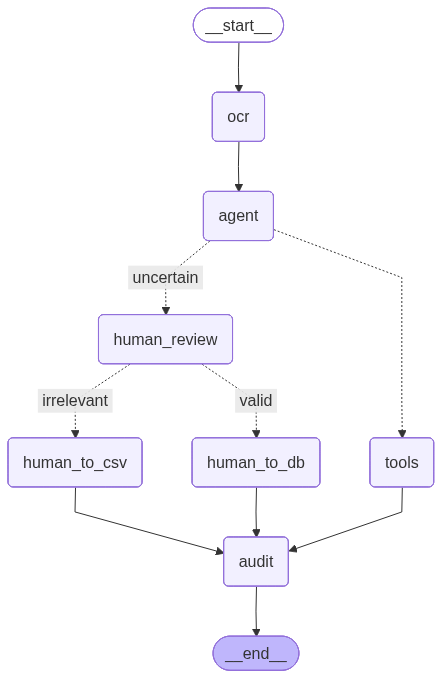

In [91]:
# -----------------------------
# BUILD GRAPH
# -----------------------------
builder = StateGraph(AgentState)

builder.add_node("ocr", ocr_node)
builder.add_node("agent", agent_node)
builder.add_node("tools", tool_node)
builder.add_node("human_review", human_review_node)
builder.add_node("human_to_db", human_to_db_node)
builder.add_node("human_to_csv", human_to_csv_node)
builder.add_node("audit", audit_node)

builder.set_entry_point("ocr")

# Flow
builder.add_edge("ocr", "agent")


# Tools → Audit
builder.add_edge("tools", "audit")

# Human → DB/CSV
builder.add_conditional_edges(
    "human_review",
    human_router,
    {
        "valid": "human_to_db",
        "irrelevant": "human_to_csv"
    }
)
builder.add_conditional_edges(
    "agent",
    agent_router,
    {
        "tools": "tools",
        "uncertain": "human_review"
    }
)
# Human outputs → Audit
builder.add_edge("human_to_db", "audit")
builder.add_edge("human_to_csv", "audit")

# End

# -----------------------------
# MEMORY (LangGraph)
# -----------------------------
memory = MemorySaver()
graph = builder.compile(checkpointer=memory)

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

# -----------------------------
# PROCESS FOLDER
# -----------------------------
def process_folder(folder_path: str):

    thread_id = "multi_agent_session"

    for file_name in os.listdir(folder_path):

        if not file_name.lower().endswith(".pdf"):
            continue

        file_path = os.path.join(folder_path, file_name)

        print(f"\n📄 Processing: {file_name}")

        graph.invoke(
            {"file_path": file_path},
            config={"configurable": {"thread_id": thread_id}}
        )


In [92]:
# -----------------------------
# RUN
# -----------------------------
if __name__ == "__main__":
    folder_path = input("Enter Folder path :").strip()

    if not os.path.exists(folder_path):
        raise ValueError("Invalid folder path")

    process_folder(folder_path)

    print("\n✅ Multi-agent processing completed!")

Enter Folder path :/content/pdf_folder/

📄 Processing: bw_doc_1.pdf
📁 Full OCR saved to: bw_doc_1.pdf_ocr.txt

📄 FILE: bw_doc_1.pdf
🔍 Keyword Type: uncertain_keyword
🔑 Keywords Found: ['behalf']
⚠️ FORCED HUMAN REVIEW (UNCERTAIN KEYWORD)

⚠️ HUMAN REVIEW REQUIRED: bw_doc_1.pdf
Keyword Type: None
Approve as VALID? (yes/no):yes
👤 Human Decision: VALID → DB

📝 AUDIT LOGGED
File: bw_doc_1.pdf
Classification: uncertain
Tool Used: None
Human Decision: valid

📄 Processing: bw_doc_3.pdf
📁 Full OCR saved to: bw_doc_3.pdf_ocr.txt

📄 FILE: bw_doc_3.pdf
🔍 Keyword Type: no_keyword
🔑 Keywords Found: []
🤖 Tool Invoked by LLM: save_to_csv_tool

📁 CSV WRITE SUCCESS
File: HIYREC/2025/207
Document Name: Request for Limited Document Production for Audit
Document Date: October 11, 2025

📝 AUDIT LOGGED
File: bw_doc_3.pdf
Classification: handled
Tool Used: None
Human Decision: valid

📄 Processing: 06_harassment_workplace.pdf
📁 Full OCR saved to: 06_harassment_workplace.pdf_ocr.txt

📄 FILE: 06_harassment_work

In [94]:
import sqlite3

with sqlite3.connect(DB_FILE) as conn:
    cursor = conn.cursor()
    cursor.execute("SELECT * FROM audit_logs")
    records = cursor.fetchall()

    print("\nAll Records from audit_logs:")
    for record in records:
        print(record)

    print(f"\nTotal Records: {len(records)}")


All Records from audit_logs:
(1, 'bw_doc_1.pdf', 'uncertain', None, 'valid', '2026-03-21 13:49:29')
(2, 'bw_doc_3.pdf', 'handled', None, 'valid', '2026-03-21 13:49:32')
(3, '06_harassment_workplace.pdf', 'handled', None, 'valid', '2026-03-21 13:49:47')
(4, '04_defamation_online_review.pdf', 'handled', None, 'valid', '2026-03-21 13:50:01')
(5, 'LOA3.pdf', 'handled', None, 'valid', '2026-03-21 13:50:08')
(6, 'LOA2.pdf', 'handled', None, 'valid', '2026-03-21 13:50:16')
(7, 'bw_doc_5.pdf', 'handled', None, 'valid', '2026-03-21 13:50:20')
(8, '01_copyright_infringement_photography.pdf', 'handled', None, 'valid', '2026-03-21 13:50:34')
(9, 'LoA1.pdf', 'handled', None, 'valid', '2026-03-21 13:50:41')
(10, '03_trade_secret_misappropriation.pdf', 'handled', None, 'valid', '2026-03-21 13:50:57')
(11, '02_trademark_infringement_tech.pdf', 'handled', None, 'valid', '2026-03-21 13:51:10')
(12, '05_patent_infringement_medical_device.pdf', 'handled', None, 'valid', '2026-03-21 13:51:25')
(13, 'bw_do